# SAFER wind-power forecasting

*State-Adaptive Forecast Error Recalibration*

## 1. Setup

In [3]:
from __future__ import annotations

import json
import platform
import time
from pathlib import Path
from typing import Dict, Iterable, List, Mapping, Sequence, Tuple

import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from catboost import CatBoostRegressor
except ImportError as exc:
    raise ImportError(
        "CatBoost is required for the 12-hour model. Install catboost before running this notebook."
    ) from exc



SEED = 123
HORIZONS = [1, 3, 6, 12, 24]
NOMINAL_LEVELS = [0.80, 0.90, 0.95]

TRAIN_FRAC = 0.55
VALIDATION_FRAC = 0.10
CALIBRATION_FRAC = 0.20
TEST_FRAC = 0.15

MIN_STATE_SIZE = 30
ACI_GAMMA = 0.005

BOOTSTRAP_BLOCK_LENGTH = 24
BOOTSTRAP_REPLICATIONS = 2000
BOOTSTRAP_CHUNK_SIZE = 200

CQR_MAX_ITER = 200
CQR_LEARNING_RATE = 0.05
CQR_MAX_LEAF_NODES = 31
CQR_MIN_SAMPLES_LEAF = 30
CQR_L2_REGULARIZATION = 0.10

EXPECTED_MODEL_READY_N = 42_312
EXPECTED_SPLIT_COUNTS = {
    "train": 23_271,
    "validation": 4_231,
    "calibration": 8_462,
    "test": 6_348,
}
EXPECTED_SELECTION = {
    1: "Linear regression",
    3: "Linear regression",
    6: "Linear regression",
    12: "CatBoost",
    24: "Linear regression",
}

TARGET_COLUMNS = {
    "target",
    "target_h1",
    "target_h3",
    "target_h6",
    "target_h12",
    "target_h24",
}
NON_FEATURE_COLUMNS = {
    "datetime",
    "season",
    "intraday_block",
    "generation_state",
    "generation_state_code",
    "split",
} | TARGET_COLUMNS

STATE_LEVELS = [
    ("season", "intraday_block", "generation_state"),
    ("season", "intraday_block"),
    ("season", "generation_state"),
    ("season",),
    tuple(),
]



def find_project_dir() -> Path:
    """Locate the SAFER project folder on the current machine."""
    candidates = [
        Path.cwd(),
        Path.cwd() / "SAFER_Wind_Applied_Energy",
        Path.home() / "Documents" / "SAFER_Wind_Applied_Energy",
        Path.home() / "OneDrive" / "Documents" / "SAFER_Wind_Applied_Energy",
    ]

    for folder in candidates:
        if (folder / "01_data" / "processed").exists():
            return folder.resolve()

    raise FileNotFoundError(
        "Could not locate the SAFER_Wind_Applied_Energy project folder. "
        "Set project_dir manually to the folder that contains 01_data/processed."
    )


def make_paths(project_dir: Path) -> Dict[str, Path]:
    project_dir = project_dir.resolve()
    results_dir = project_dir / "04_results" / "revision"

    paths = {
        "project": project_dir,
        "processed": project_dir / "01_data" / "processed",
        "results": results_dir,
        "tables": results_dir / "tables",
        "predictions": results_dir / "predictions",
        "figures": project_dir / "05_figures" / "jpg",
    }

    for key in ["results", "tables", "predictions", "figures"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    return paths


def regional_horizon_path(processed_dir: Path, horizon: int) -> Path:
    return processed_dir / f"safer_wind_eskom_era5_regional_model_dataset_h{horizon}.csv"


def verify_required_inputs(processed_dir: Path, require_figure_data: bool = True) -> None:
    missing = [
        regional_horizon_path(processed_dir, h)
        for h in HORIZONS
        if not regional_horizon_path(processed_dir, h).exists()
    ]

    if require_figure_data:
        figure_data = processed_dir / "safer_wind_eskom_era5_merged.csv"
        if not figure_data.exists():
            missing.append(figure_data)

    if missing:
        formatted = "\n".join(f"  - {p}" for p in missing)
        raise FileNotFoundError(
            "Required input file(s) are missing:\n"
            f"{formatted}\n\n"
            "Place the processed data in 01_data/processed/ before running the notebook."
        )

## 2. Data loading

In [5]:
np.random.seed(SEED)

project_dir = find_project_dir()
paths = make_paths(project_dir)

verify_required_inputs(
    paths["processed"],
    require_figure_data=True
)

eda_file = paths["processed"] / "safer_wind_eskom_era5_merged.csv"

df_eda = pd.read_csv(eda_file)
df_eda["datetime"] = pd.to_datetime(df_eda["datetime"])
df_eda["hour"] = df_eda["datetime"].dt.hour
df_eda["month"] = df_eda["datetime"].dt.month

def assign_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    if month in [3, 4, 5]:
        return "Autumn"
    if month in [6, 7, 8]:
        return "Winter"
    return "Spring"

df_eda["season"] = df_eda["month"].apply(assign_season)
df_eda = df_eda.sort_values("datetime").reset_index(drop=True)

print("Project directory:", paths["project"])
print("Processed data:", paths["processed"])
print("EDA observations:", f"{len(df_eda):,}")
print(
    "Period:",
    df_eda["datetime"].min(),
    "to",
    df_eda["datetime"].max()
)

display(df_eda.head())

Project directory: C:\Users\komet\OneDrive\Documents\SAFER_Wind_Applied_Energy
Processed data: C:\Users\komet\OneDrive\Documents\SAFER_Wind_Applied_Energy\01_data\processed
EDA observations: 42,672
Period: 2019-04-01 00:00:00 to 2024-02-11 23:00:00


,datetime,wind_generation_mw,u10,v10,u100,v100,ws10,ws100,wd10,wd100,temperature_c,surface_pressure_hpa,hour,month,season
0,2019-04-01 00:00:00,746.888,1.077047,0.518592,1.700624,0.800900,4.245641,6.481047,191.77762,192.99496,18.952839,923.73880,0,4,Autumn
1,2019-04-01 01:00:00,937.058,1.092684,0.633805,1.710622,1.024798,4.267048,6.520617,186.48752,189.66277,18.824337,923.65607,1,4,Autumn
2,2019-04-01 02:00:00,982.304,1.130648,0.740673,1.703342,1.224261,4.320232,6.596758,191.19408,190.05907,17.926735,923.59690,2,4,Autumn
3,2019-04-01 03:00:00,980.428,1.177700,0.812912,1.721221,1.361344,4.344252,6.616376,192.53001,191.62470,17.968988,923.76890,3,4,Autumn
4,2019-04-01 04:00:00,1035.222,1.214076,0.910952,1.674210,1.514658,4.365195,6.578378,194.69750,193.18776,17.873520,924.22546,4,4,Autumn


## 3. Exploratory data analysis

### 3.1 Data quality and descriptive statistics

In [8]:
eda_columns = [
    "wind_generation_mw",
    "ws10",
    "ws100",
    "temperature_c",
    "surface_pressure_hpa",
    "u100",
    "v100",
]

missing_columns = [c for c in eda_columns if c not in df_eda.columns]
if missing_columns:
    raise KeyError(f"Missing EDA columns: {missing_columns}")

overview = pd.DataFrame(
    {
        "Measure": [
            "Observations",
            "Start",
            "End",
            "Duplicate timestamps",
            "Missing wind generation",
        ],
        "Value": [
            f"{len(df_eda):,}",
            df_eda["datetime"].min(),
            df_eda["datetime"].max(),
            int(df_eda["datetime"].duplicated().sum()),
            int(df_eda["wind_generation_mw"].isna().sum()),
        ],
    }
)

display(overview)

display(
    df_eda[eda_columns]
    .describe()
    .T
    .round(3)
)

,Measure,Value
0,Observations,"42,672"
1,Start,2019-04-01 00:00:00
2,End,2024-02-11 23:00:00
3,Duplicate timestamps,0
4,Missing wind generation,0


,count,mean,std,min,25%,50%,75%,max
wind_generation_mw,42672.0,995.833,548.396,19.803,575.313,916.260,1327.505,3102.225
ws10,42672.0,4.206,0.894,2.137,3.556,4.096,4.731,8.805
ws100,42672.0,5.971,1.225,2.818,5.094,5.846,6.732,11.878
temperature_c,42672.0,19.301,5.504,3.379,15.383,19.658,23.291,33.453
surface_pressure_hpa,42672.0,925.390,3.968,912.859,922.483,924.887,927.899,941.399
u100,42672.0,-0.587,2.333,-7.328,-2.239,-0.703,0.855,9.684
v100,42672.0,-0.331,2.612,-10.125,-2.088,-0.378,1.432,8.216


### 3.2 Hourly wind generation and 100 m wind speed

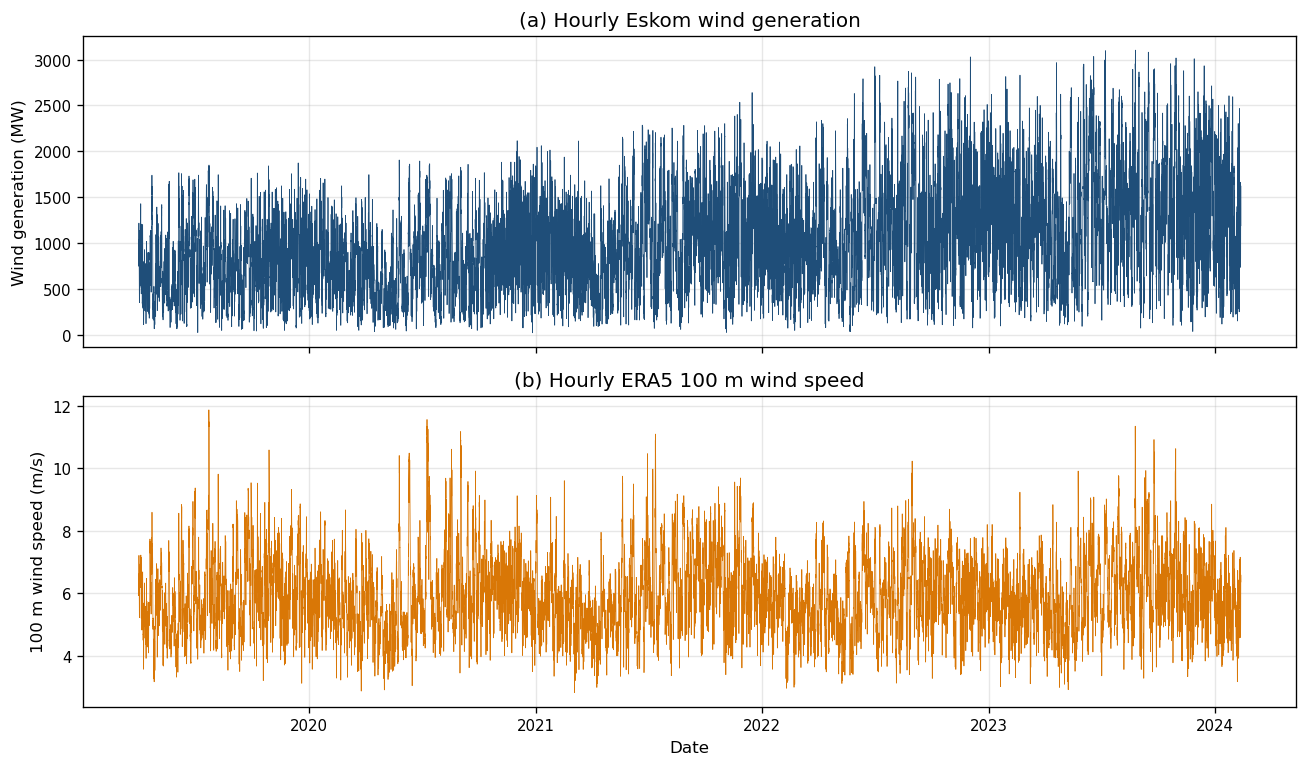

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
    }
)

fig, axes = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True)

axes[0].plot(
    df_eda["datetime"],
    df_eda["wind_generation_mw"],
    linewidth=0.45,
    color="#1f4e79",
)
axes[0].set_ylabel("Wind generation (MW)")
axes[0].set_title("(a) Hourly Eskom wind generation")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    df_eda["datetime"],
    df_eda["ws100"],
    linewidth=0.45,
    color="#d97706",
)
axes[1].set_ylabel("100 m wind speed (m/s)")
axes[1].set_xlabel("Date")
axes[1].set_title("(b) Hourly ERA5 100 m wind speed")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 3.3 Monthly wind generation and wind speed

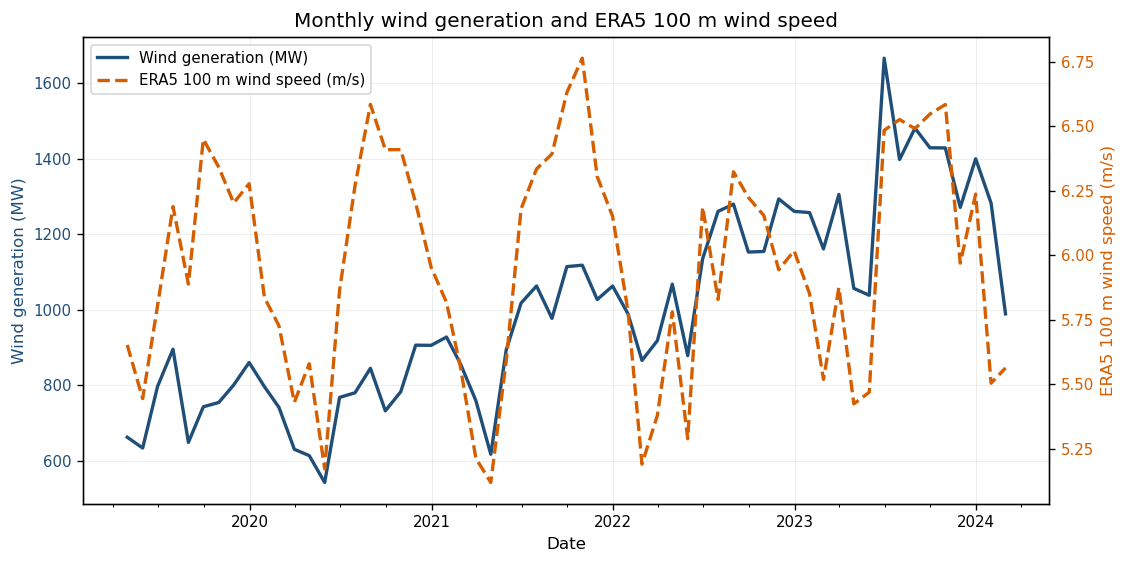

In [12]:
monthly = (
    df_eda.set_index("datetime")
          .resample("ME")
          .agg({
              "wind_generation_mw": "mean",
              "ws100": "mean"
          })
          .reset_index()
)

wind_colour = "#1F4E79"
era5_colour = "#D55E00"

fig, ax1 = plt.subplots(figsize=(9.5, 4.8))

line1, = ax1.plot(
    monthly["datetime"],
    monthly["wind_generation_mw"],
    linewidth=2.0,
    color=wind_colour,
    label="Wind generation (MW)"
)

ax1.set_ylabel("Wind generation (MW)", color=wind_colour)
ax1.tick_params(axis="y", labelcolor=wind_colour)
ax1.set_xlabel("Date")
ax1.grid(True, linewidth=0.35, alpha=0.35)

ax2 = ax1.twinx()

line2, = ax2.plot(
    monthly["datetime"],
    monthly["ws100"],
    linewidth=2.0,
    linestyle="--",
    color=era5_colour,
    label="ERA5 100 m wind speed (m/s)"
)

ax2.set_ylabel("ERA5 100 m wind speed (m/s)", color=era5_colour)
ax2.tick_params(axis="y", labelcolor=era5_colour)

ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))

ax1.set_title("Monthly wind generation and ERA5 100 m wind speed")

ax1.legend(
    handles=[line1, line2],
    loc="upper left",
    frameon=True
)

fig.tight_layout()
plt.show()

### 3.4 Wind-speed and generation relationship

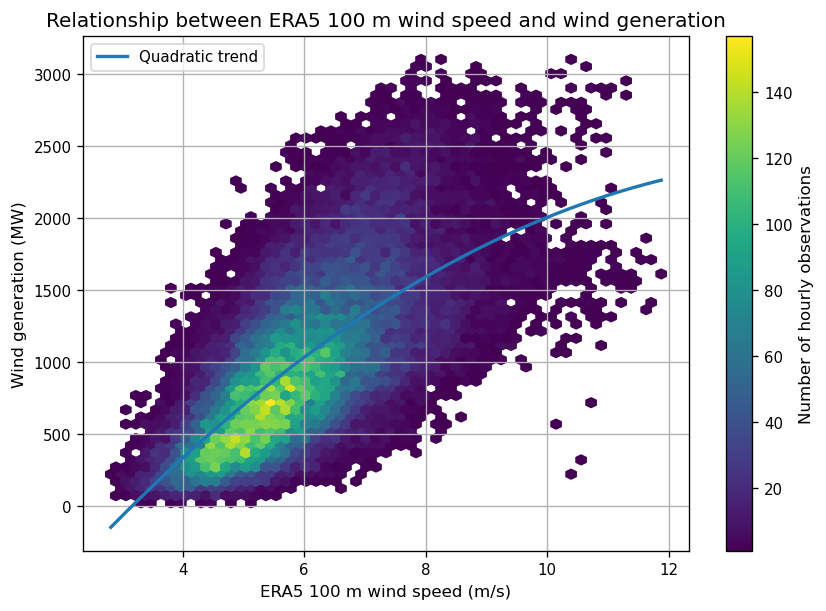

In [14]:
fig, ax = plt.subplots(figsize=(7.2, 5.2))

hb = ax.hexbin(
    df_eda["ws100"],
    df_eda["wind_generation_mw"],
    gridsize=55,
    mincnt=1
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("Number of hourly observations")

ax.set_xlabel("ERA5 100 m wind speed (m/s)")
ax.set_ylabel("Wind generation (MW)")
ax.set_title("Relationship between ERA5 100 m wind speed and wind generation")
ax.grid(True)

x = df_eda["ws100"].to_numpy()
y = df_eda["wind_generation_mw"].to_numpy()

valid = np.isfinite(x) & np.isfinite(y)
x_valid = x[valid]
y_valid = y[valid]

coeffs = np.polyfit(x_valid, y_valid, deg=2)
x_line = np.linspace(x_valid.min(), x_valid.max(), 300)
y_line = coeffs[0] * x_line**2 + coeffs[1] * x_line + coeffs[2]

ax.plot(
    x_line,
    y_line,
    linewidth=2.0,
    linestyle="-",
    label="Quadratic trend"
)

ax.legend(loc="upper left", frameon=True)

fig.tight_layout()
plt.show()

### 3.5 Intraday behaviour

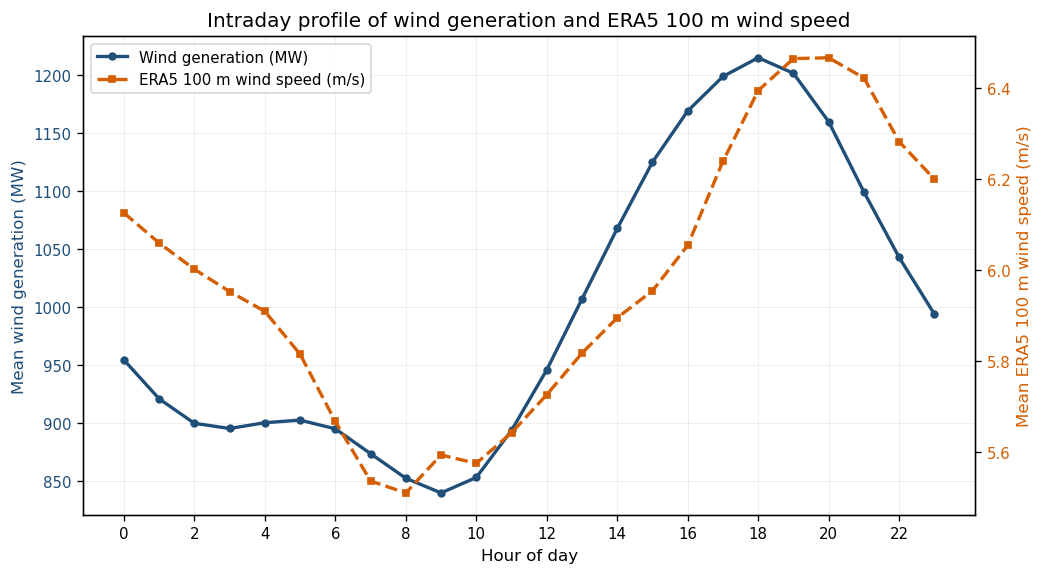

In [16]:
if "hour" not in df_eda.columns:
    df_eda["hour"] = pd.to_datetime(df_eda["datetime"]).dt.hour

hourly_profile = (
    df_eda.groupby("hour")
          .agg(
              wind_generation_mean=("wind_generation_mw", "mean"),
              wind_generation_sd=("wind_generation_mw", "std"),
              ws100_mean=("ws100", "mean"),
              ws100_sd=("ws100", "std")
          )
          .reset_index()
)

wind_colour = "#1F4E79"
era5_colour = "#D55E00"

fig, ax1 = plt.subplots(figsize=(8.8, 4.9))

line1, = ax1.plot(
    hourly_profile["hour"],
    hourly_profile["wind_generation_mean"],
    marker="o",
    markersize=4,
    linewidth=2.0,
    color=wind_colour,
    label="Wind generation (MW)"
)

ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Mean wind generation (MW)", color=wind_colour)
ax1.tick_params(axis="y", labelcolor=wind_colour)
ax1.set_xticks(range(0, 24, 2))
ax1.grid(True, linewidth=0.35, alpha=0.35)

ax2 = ax1.twinx()

line2, = ax2.plot(
    hourly_profile["hour"],
    hourly_profile["ws100_mean"],
    marker="s",
    markersize=4,
    linewidth=2.0,
    linestyle="--",
    color=era5_colour,
    label="ERA5 100 m wind speed (m/s)"
)

ax2.set_ylabel("Mean ERA5 100 m wind speed (m/s)", color=era5_colour)
ax2.tick_params(axis="y", labelcolor=era5_colour)

ax1.set_title("Intraday profile of wind generation and ERA5 100 m wind speed")

ax1.legend(
    handles=[line1, line2],
    loc="upper left",
    frameon=True
)

fig.tight_layout()
plt.show()

### 3.6 Seasonal behaviour

,count,mean,std,median,min,max
season,,,,,,
Summer,10416,1028.39,505.63,967.36,19.80,3028.06
Autumn,10296,830.69,483.80,754.90,32.06,2965.25
Winter,11040,1067.85,601.45,969.18,22.18,3102.22
Spring,10920,1047.67,557.09,975.77,24.01,3080.05


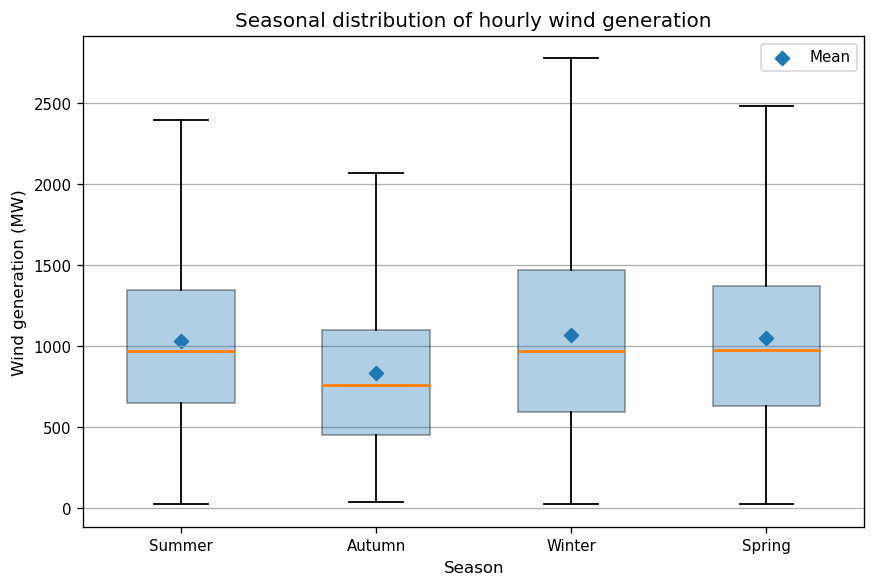

In [18]:
if "month" not in df_eda.columns:
    df_eda["month"] = pd.to_datetime(df_eda["datetime"]).dt.month

if "season" not in df_eda.columns:
    def assign_season(month):
        if month in [12, 1, 2]:
            return "Summer"
        if month in [3, 4, 5]:
            return "Autumn"
        if month in [6, 7, 8]:
            return "Winter"
        return "Spring"

    df_eda["season"] = df_eda["month"].apply(assign_season)

season_order = ["Summer", "Autumn", "Winter", "Spring"]

season_summary = (
    df_eda.groupby("season")["wind_generation_mw"]
          .agg(["count", "mean", "std", "median", "min", "max"])
          .reindex(season_order)
          .round(2)
)

display(season_summary)

season_data = [
    df_eda.loc[df_eda["season"] == season, "wind_generation_mw"].dropna()
    for season in season_order
]

season_means = [
    values.mean()
    for values in season_data
]

fig, ax = plt.subplots(figsize=(7.4, 5.0))

box = ax.boxplot(
    season_data,
    labels=season_order,
    showfliers=False,
    patch_artist=True,
    widths=0.55,
    medianprops={"linewidth": 1.7},
    boxprops={"linewidth": 1.1},
    whiskerprops={"linewidth": 1.1},
    capprops={"linewidth": 1.1}
)

for patch in box["boxes"]:
    patch.set_alpha(0.35)

ax.scatter(
    np.arange(1, len(season_order) + 1),
    season_means,
    marker="D",
    s=35,
    label="Mean"
)

ax.set_xlabel("Season")
ax.set_ylabel("Wind generation (MW)")
ax.set_title("Seasonal distribution of hourly wind generation")
ax.grid(True, axis="y")
ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
plt.show()

### 3.7 Correlation structure

,wind_generation_mw,ws10,ws100,temperature_c,surface_pressure_hpa,u100,v100
wind_generation_mw,1.000,0.600,0.676,-0.000,-0.160,0.182,0.018
ws10,0.600,1.000,0.847,0.192,-0.119,0.200,0.027
ws100,0.676,0.847,1.000,-0.165,-0.041,0.110,-0.005
temperature_c,-0.000,0.192,-0.165,1.000,-0.548,0.021,0.034
surface_pressure_hpa,-0.160,-0.119,-0.041,-0.548,1.000,-0.316,-0.099
u100,0.182,0.200,0.110,0.021,-0.316,1.000,-0.011
v100,0.018,0.027,-0.005,0.034,-0.099,-0.011,1.000


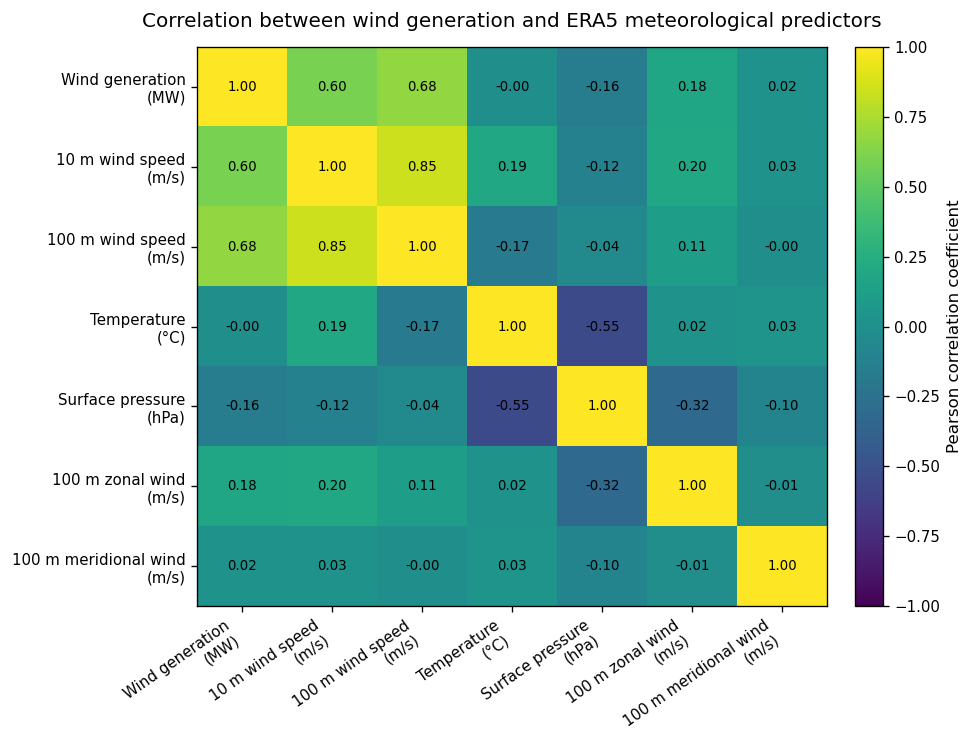

In [20]:
corr_cols = [
    "wind_generation_mw",
    "ws10",
    "ws100",
    "temperature_c",
    "surface_pressure_hpa",
    "u100",
    "v100"
]

label_map = {
    "wind_generation_mw": "Wind generation\n(MW)",
    "ws10": "10 m wind speed\n(m/s)",
    "ws100": "100 m wind speed\n(m/s)",
    "temperature_c": "Temperature\n(°C)",
    "surface_pressure_hpa": "Surface pressure\n(hPa)",
    "u100": "100 m zonal wind\n(m/s)",
    "v100": "100 m meridional wind\n(m/s)"
}

corr = df_eda[corr_cols].corr()
labels = [label_map[col] for col in corr_cols]

display(corr.round(3))

fig, ax = plt.subplots(figsize=(8.2, 6.4))

im = ax.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(corr_cols)))
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_xticklabels(labels, rotation=35, ha="right")
ax.set_yticklabels(labels)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        value = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation coefficient")

ax.set_title(
    "Correlation between wind generation and ERA5 meteorological predictors",
    pad=12
)

fig.tight_layout()
plt.show()

### 3.8 Seasonal wind-speed and generation relationships

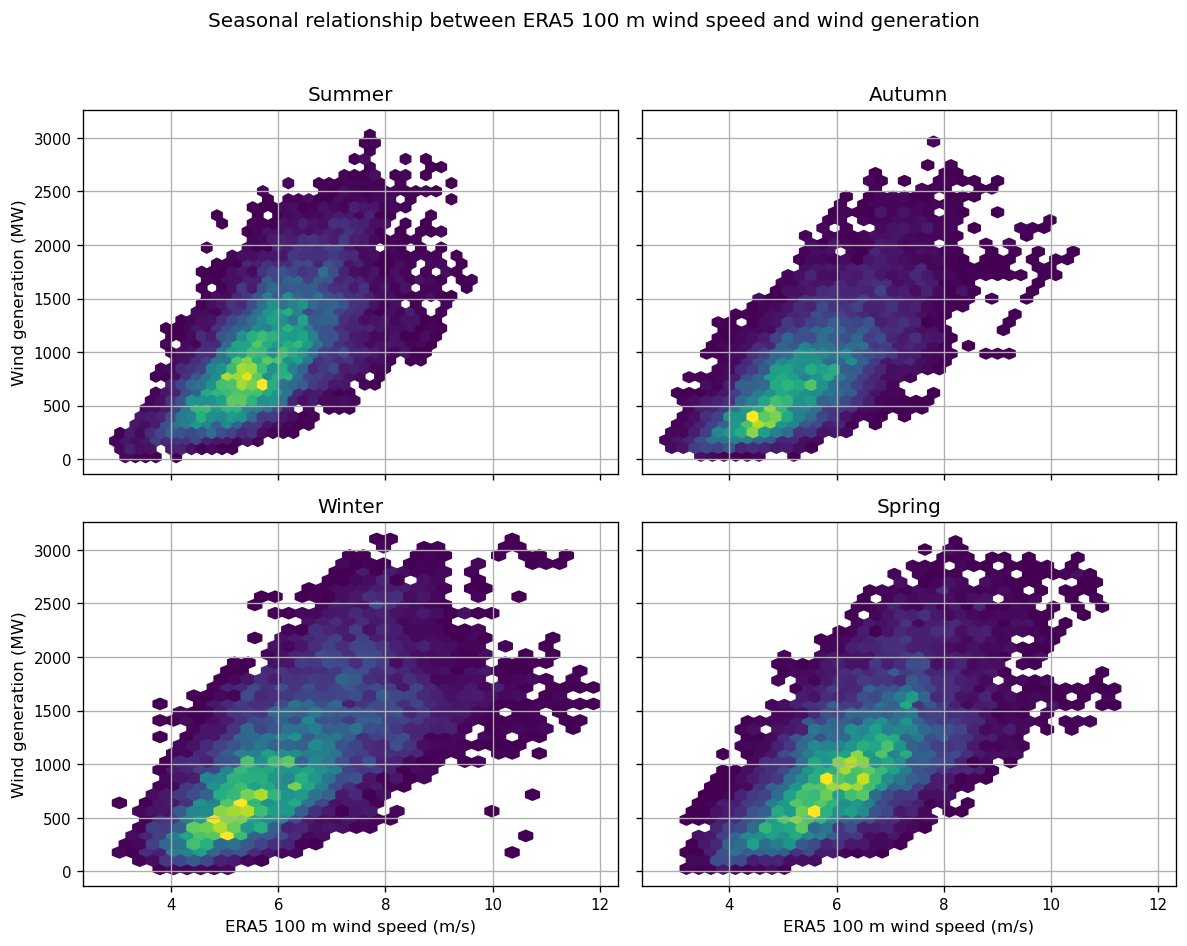

In [22]:
if "month" not in df_eda.columns:
    df_eda["month"] = pd.to_datetime(df_eda["datetime"]).dt.month

if "season" not in df_eda.columns:
    def assign_season(month):
        if month in [12, 1, 2]:
            return "Summer"
        if month in [3, 4, 5]:
            return "Autumn"
        if month in [6, 7, 8]:
            return "Winter"
        return "Spring"

    df_eda["season"] = df_eda["month"].apply(assign_season)

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, season in zip(axes, season_order):
    season_df = df_eda[df_eda["season"] == season]

    hb = ax.hexbin(
        season_df["ws100"],
        season_df["wind_generation_mw"],
        gridsize=35,
        mincnt=1
    )

    ax.set_title(season)
    ax.grid(True)

    if ax in axes[2:]:
        ax.set_xlabel("ERA5 100 m wind speed (m/s)")

    if ax in [axes[0], axes[2]]:
        ax.set_ylabel("Wind generation (MW)")

fig.suptitle(
    "Seasonal relationship between ERA5 100 m wind speed and wind generation",
    y=0.98,
    fontsize=12
)

fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 4. Chronological data split

In [24]:
def chronological_split(
    df: pd.DataFrame,
    train_frac: float = TRAIN_FRAC,
    validation_frac: float = VALIDATION_FRAC,
    calibration_frac: float = CALIBRATION_FRAC,
    test_frac: float = TEST_FRAC,
) -> Dict[str, pd.DataFrame]:
    fractions = np.array(
        [train_frac, validation_frac, calibration_frac, test_frac], dtype=float
    )
    if not np.isclose(fractions.sum(), 1.0):
        raise ValueError("Split fractions must sum to one.")

    data = df.sort_values("datetime").reset_index(drop=True).copy()
    n = len(data)

    i1 = int(np.floor(n * train_frac))
    i2 = i1 + int(np.floor(n * validation_frac))
    i3 = i2 + int(np.floor(n * calibration_frac))

    parts = {
        "train": data.iloc[:i1].copy(),
        "validation": data.iloc[i1:i2].copy(),
        "calibration": data.iloc[i2:i3].copy(),
        "test": data.iloc[i3:].copy(),
    }

    for name, part in parts.items():
        if part.empty:
            raise ValueError(f"The {name} split is empty.")
        part["split"] = name

    # Check final sample sizes.
    if n == EXPECTED_MODEL_READY_N:
        actual_counts = {name: len(part) for name, part in parts.items()}
        if actual_counts != EXPECTED_SPLIT_COUNTS:
            raise RuntimeError(
                f"Split counts differ from the analysis: {actual_counts} "
                f"!= {EXPECTED_SPLIT_COUNTS}"
            )

    return parts


def split_audit(parts: Mapping[str, pd.DataFrame], horizon: int) -> pd.DataFrame:
    total = sum(len(x) for x in parts.values())
    rows = []
    for name in ["train", "validation", "calibration", "test"]:
        part = parts[name]
        rows.append(
            {
                "horizon_hours": horizon,
                "subset": name,
                "start_datetime": part["datetime"].min(),
                "end_datetime": part["datetime"].max(),
                "n_observations": len(part),
                "share": len(part) / total,
            }
        )
    return pd.DataFrame(rows)


def get_feature_columns(df: pd.DataFrame) -> List[str]:
    """Return numeric point-model features while excluding targets and SAFER states."""
    return [
        c
        for c in df.columns
        if c not in NON_FEATURE_COLUMNS
        and not c.startswith("target_h")
        and not c.startswith("generation_state")
        and pd.api.types.is_numeric_dtype(df[c])
    ]


def assert_feature_safety(feature_cols: Sequence[str]) -> None:
    forbidden = [
        c
        for c in feature_cols
        if c.startswith("target_h") or c.startswith("generation_state")
    ]
    if forbidden:
        raise RuntimeError(
            "Leakage-prone/state-derived columns entered the point model: "
            f"{forbidden}"
        )


# ============================================================

## 5. State variables

In [26]:
def add_calendar_states(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    dt = pd.to_datetime(out["datetime"])

    month = dt.dt.month
    out["season"] = np.select(
        [
            month.isin([12, 1, 2]),
            month.isin([3, 4, 5]),
            month.isin([6, 7, 8]),
        ],
        ["summer", "autumn", "winter"],
        default="spring",
    )

    hour = dt.dt.hour
    out["intraday_block"] = pd.cut(
        hour,
        bins=[-1, 5, 11, 17, 23],
        labels=["night", "morning", "afternoon", "evening"],
    ).astype(str)

    return out


def estimate_generation_thresholds(
    calibration_df: pd.DataFrame,
    source_col: str = "wind_generation_mw",
) -> Dict[str, float]:
    if source_col not in calibration_df:
        raise KeyError(f"Missing generation source column: {source_col}")

    low, high = calibration_df[source_col].quantile([1 / 3, 2 / 3]).to_numpy()
    return {
        "low_threshold": float(low),
        "high_threshold": float(high),
        "source": "calibration_only",
    }


def apply_generation_states(
    df: pd.DataFrame,
    thresholds: Mapping[str, float],
    source_col: str = "wind_generation_mw",
) -> pd.DataFrame:
    out = df.copy()
    low = thresholds["low_threshold"]
    high = thresholds["high_threshold"]

    out["generation_state"] = np.select(
        [out[source_col] <= low, out[source_col] <= high],
        ["low", "medium"],
        default="high",
    )
    return out


# ============================================================

## 6. Point forecast models

In [28]:
def rmse(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mae(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    return float(mean_absolute_error(y_true, y_pred))


def smape(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator > 0
    return float(
        100 * np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask])
    )


def mase(
    y_true: Sequence[float],
    y_pred: Sequence[float],
    y_reference: Sequence[float],
    seasonality: int = 24,
) -> float:
    y_reference = np.asarray(y_reference, dtype=float)
    scale = np.mean(
        np.abs(y_reference[seasonality:] - y_reference[:-seasonality])
    )
    if scale <= 0:
        return np.nan
    return float(
        np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))) / scale
    )


def deterministic_metrics(
    y_true: Sequence[float],
    y_pred: Sequence[float],
    y_reference: Sequence[float],
) -> Dict[str, float]:
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE": mae(y_true, y_pred),
        "MASE": mase(y_true, y_pred, y_reference),
        "sMAPE": smape(y_true, y_pred),
    }


def candidate_models() -> Dict[str, object]:
    return {
        "Linear regression": Pipeline(
            [
                ("scale", StandardScaler()),
                ("model", LinearRegression()),
            ]
        ),
        "Random forest": RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            max_features="sqrt",
            n_jobs=-1,
            random_state=SEED,
        ),
        "CatBoost": CatBoostRegressor(
            iterations=800,
            depth=8,
            learning_rate=0.04,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False,
            allow_writing_files=False,
        ),
    }


def screen_models(
    train: pd.DataFrame,
    validation: pd.DataFrame,
    feature_cols: Sequence[str],
) -> Tuple[pd.DataFrame, str]:
    X_train = train[list(feature_cols)]
    y_train = train["target"].to_numpy()
    X_validation = validation[list(feature_cols)]
    y_validation = validation["target"].to_numpy()

    rows = []
    for name, estimator in candidate_models().items():
        model = clone(estimator)
        model.fit(X_train, y_train)
        prediction = np.maximum(0, model.predict(X_validation))
        rows.append(
            {
                "model": name,
                **deterministic_metrics(y_validation, prediction, y_train),
            }
        )

    results = (
        pd.DataFrame(rows)
        .sort_values(["RMSE", "MAE"])
        .reset_index(drop=True)
    )
    selected_name = str(results.loc[0, "model"])
    return results, selected_name


def refit_selected_model(
    model_name: str,
    train: pd.DataFrame,
    validation: pd.DataFrame,
    feature_cols: Sequence[str],
):
    model = clone(candidate_models()[model_name])
    train_validation = pd.concat([train, validation], ignore_index=True)
    model.fit(
        train_validation[list(feature_cols)],
        train_validation["target"].to_numpy(),
    )
    return model, train_validation


# ============================================================

## 7. Global and SAFER intervals

In [30]:
def conformal_quantile(scores: Sequence[float], alpha: float) -> float:
    values = np.sort(np.asarray(scores, dtype=float))
    n = len(values)
    if n == 0:
        return np.nan

    k = int(np.ceil((n + 1) * (1 - alpha)))
    k = min(max(k, 1), n)
    return float(values[k - 1])


def build_safer_quantiles(
    calibration: pd.DataFrame,
    residual_col: str,
    alpha: float,
    min_state_size: int = MIN_STATE_SIZE,
):
    quantiles = {}
    counts = {}

    for level in STATE_LEVELS:
        if not level:
            scores = calibration[residual_col].abs().to_numpy()
            quantiles[(level, "global")] = conformal_quantile(scores, alpha)
            counts[(level, "global")] = len(scores)
            continue

        grouped = calibration.groupby(list(level), observed=True)
        for key, group in grouped:
            if not isinstance(key, tuple):
                key = (key,)
            scores = group[residual_col].abs().to_numpy()
            counts[(level, key)] = len(scores)
            if len(scores) >= min_state_size:
                quantiles[(level, key)] = conformal_quantile(scores, alpha)

    return quantiles, counts


def lookup_safer_quantile(row: pd.Series, quantiles):
    for level in STATE_LEVELS:
        if not level:
            return quantiles[(level, "global")], "global"

        key = tuple(row[col] for col in level)
        lookup = (level, key)
        if lookup in quantiles:
            return quantiles[lookup], " × ".join(level)

    raise RuntimeError("Global fallback quantile was not available.")


def apply_global_and_safer(
    calibration: pd.DataFrame,
    test: pd.DataFrame,
    calibration_pred: Sequence[float],
    test_pred: Sequence[float],
    nominal: float,
):
    alpha = 1 - nominal
    cal = calibration.copy()
    out = test.copy()

    cal["point_prediction"] = np.asarray(calibration_pred, dtype=float)
    cal["residual"] = cal["target"] - cal["point_prediction"]
    out["point_prediction"] = np.asarray(test_pred, dtype=float)

    # Global split conformal.
    q_global = conformal_quantile(cal["residual"].abs(), alpha)
    out["global_lower"] = np.maximum(
        0, out["point_prediction"] - q_global
    )
    out["global_upper"] = out["point_prediction"] + q_global

    # State-Adaptive Forecast Error Recalibration (SAFER).
    safer_quantiles, state_counts = build_safer_quantiles(
        cal, "residual", alpha
    )
    chosen = out.apply(
        lambda row: lookup_safer_quantile(row, safer_quantiles), axis=1
    )
    out["safer_q"] = [item[0] for item in chosen]
    out["fallback_level"] = [item[1] for item in chosen]
    out["safer_lower"] = np.maximum(
        0, out["point_prediction"] - out["safer_q"]
    )
    out["safer_upper"] = out["point_prediction"] + out["safer_q"]

    return out, cal, state_counts


# ============================================================

## 8. CQR and ACI benchmarks

In [32]:
def fit_cqr(
    train_validation: pd.DataFrame,
    calibration: pd.DataFrame,
    test: pd.DataFrame,
    feature_cols: Sequence[str],
    nominal: float,
):
    """
    Conformalized quantile regression comparator used in the analysis.

    Two HistGradientBoostingRegressor quantile models are fitted on
    train+validation and then conformalized on the calibration subset.
    """
    alpha = 1 - nominal
    lower_tau = alpha / 2
    upper_tau = 1 - alpha / 2

    X_fit = train_validation[list(feature_cols)]
    y_fit = train_validation["target"].to_numpy()

    def make_quantile_model(q: float):
        return HistGradientBoostingRegressor(
            loss="quantile",
            quantile=q,
            max_iter=CQR_MAX_ITER,
            learning_rate=CQR_LEARNING_RATE,
            max_leaf_nodes=CQR_MAX_LEAF_NODES,
            min_samples_leaf=CQR_MIN_SAMPLES_LEAF,
            l2_regularization=CQR_L2_REGULARIZATION,
            early_stopping=False,
            random_state=SEED,
        )

    lower_model = make_quantile_model(lower_tau)
    upper_model = make_quantile_model(upper_tau)

    lower_model.fit(X_fit, y_fit)
    upper_model.fit(X_fit, y_fit)

    cal_lower = lower_model.predict(calibration[list(feature_cols)])
    cal_upper = upper_model.predict(calibration[list(feature_cols)])
    cal_y = calibration["target"].to_numpy()

    scores = np.maximum(cal_lower - cal_y, cal_y - cal_upper)
    q = conformal_quantile(scores, alpha)

    test_lower = lower_model.predict(test[list(feature_cols)])
    test_upper = upper_model.predict(test[list(feature_cols)])

    return np.maximum(0, test_lower - q), test_upper + q


def adaptive_conformal_intervals(
    calibration_scores: Sequence[float],
    test_pred: Sequence[float],
    y_test: Sequence[float],
    nominal: float,
    gamma: float = ACI_GAMMA,
):
    scores = np.asarray(calibration_scores, dtype=float)
    prediction = np.asarray(test_pred, dtype=float)
    y = np.asarray(y_test, dtype=float)

    target_alpha = 1 - nominal
    alpha_t = target_alpha

    lowers = []
    uppers = []
    alpha_path = []

    for point_forecast, actual in zip(prediction, y):
        alpha_t = float(np.clip(alpha_t, 0.001, 0.50))
        q = conformal_quantile(scores, alpha_t)

        lower = max(0, point_forecast - q)
        upper = point_forecast + q
        miss = float(actual < lower or actual > upper)

        lowers.append(lower)
        uppers.append(upper)
        alpha_path.append(alpha_t)

        alpha_t = alpha_t + gamma * (target_alpha - miss)

    return (
        np.asarray(lowers),
        np.asarray(uppers),
        np.asarray(alpha_path),
    )


# ============================================================

## 9. Evaluation measures

In [34]:
def interval_metrics(
    y: Sequence[float],
    lower: Sequence[float],
    upper: Sequence[float],
    nominal: float,
) -> Dict[str, float]:
    y = np.asarray(y, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    alpha = 1 - nominal
    covered = (y >= lower) & (y <= upper)
    width = upper - lower

    winkler = width.copy()
    winkler = np.where(
        y < lower,
        width + (2 / alpha) * (lower - y),
        winkler,
    )
    winkler = np.where(
        y > upper,
        width + (2 / alpha) * (y - upper),
        winkler,
    )

    picp = covered.mean()
    return {
        "PICP": float(picp),
        "MPIW": float(width.mean()),
        "coverage_error": float(abs(picp - nominal)),
        "Winkler": float(winkler.mean()),
    }


def conditional_interval_metrics(
    df: pd.DataFrame,
    method: str,
    nominal: float,
    group_col: str,
) -> pd.DataFrame:
    rows = []
    for level, group in df.groupby(group_col, observed=True):
        metrics = interval_metrics(
            group["target"],
            group[f"{method}_lower"],
            group[f"{method}_upper"],
            nominal,
        )
        rows.append(
            {
                "group_variable": group_col,
                "group_level": level,
                "method": method,
                "nominal": nominal,
                "n": len(group),
                **metrics,
            }
        )
    return pd.DataFrame(rows)


def fallback_frequency(df: pd.DataFrame) -> pd.DataFrame:
    out = (
        df["fallback_level"]
        .value_counts(dropna=False)
        .rename_axis("fallback_level")
        .reset_index(name="n")
    )
    out["frequency"] = out["n"] / len(df)
    return out


# ============================================================

## 10. Statistical tests

In [36]:
def newey_west_variance(x: Sequence[float], lag: int) -> float:
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)

    gamma0 = np.dot(x, x) / n
    long_run_variance = gamma0

    for k in range(1, lag + 1):
        weight = 1 - k / (lag + 1)
        gamma = np.dot(x[k:], x[:-k]) / n
        long_run_variance += 2 * weight * gamma

    return float(max(long_run_variance, 1e-12))


def diebold_mariano(
    loss_selected: Sequence[float],
    loss_benchmark: Sequence[float],
    horizon: int,
) -> Dict[str, float]:
    differential = (
        np.asarray(loss_selected, dtype=float)
        - np.asarray(loss_benchmark, dtype=float)
    )
    lag = max(horizon - 1, 0)
    variance = newey_west_variance(differential, lag) / len(differential)
    statistic = differential.mean() / np.sqrt(variance)
    p_value = 2 * (1 - stats.norm.cdf(abs(statistic)))

    return {
        "DM_statistic": float(statistic),
        "p_value": float(p_value),
        "NW_lag": int(lag),
    }


def pointwise_winkler(
    y: Sequence[float],
    lower: Sequence[float],
    upper: Sequence[float],
    nominal: float,
) -> np.ndarray:
    y = np.asarray(y, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)

    alpha = 1 - nominal
    width = upper - lower
    score = width.copy()

    score = np.where(
        y < lower,
        width + (2 / alpha) * (lower - y),
        score,
    )
    score = np.where(
        y > upper,
        width + (2 / alpha) * (y - upper),
        score,
    )
    return score


def moving_block_bootstrap_paired_statistics(
    diff_map: Mapping[str, Sequence[float]],
    block_length: int = BOOTSTRAP_BLOCK_LENGTH,
    n_rep: int = BOOTSTRAP_REPLICATIONS,
    seed: int = SEED,
    chunk_size: int = BOOTSTRAP_CHUNK_SIZE,
) -> pd.DataFrame:
    """
    Paired moving-block bootstrap used in the analysis.

    Positive differences are defined to favour SAFER:
      coverage: SAFER - Global
      width:    Global - SAFER
      Winkler:  Global - SAFER
    """
    arrays = {
        name: np.asarray(values, dtype=float)
        for name, values in diff_map.items()
    }
    lengths = {len(values) for values in arrays.values()}

    if len(lengths) != 1:
        raise ValueError(
            "All paired-difference series must have equal length."
        )

    n = lengths.pop()
    if n < block_length:
        raise ValueError(
            "Series is shorter than the bootstrap block length."
        )

    local_rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(n / block_length))
    max_start = n - block_length + 1
    offsets = np.arange(block_length, dtype=np.int32)

    bootstrap_means = {
        name: np.empty(n_rep, dtype=float)
        for name in arrays
    }

    for low in range(0, n_rep, chunk_size):
        high = min(low + chunk_size, n_rep)
        m = high - low

        chosen = local_rng.integers(
            0,
            max_start,
            size=(m, n_blocks),
            endpoint=False,
            dtype=np.int32,
        )
        indices = (
            chosen[..., None] + offsets
        ).reshape(m, -1)[:, :n]

        for name, values in arrays.items():
            bootstrap_means[name][low:high] = (
                values[indices].mean(axis=1)
            )

    rows = []
    for name, values in arrays.items():
        observed = float(values.mean())
        distribution = bootstrap_means[name]
        centered = distribution - observed
        p_value = float(
            np.mean(np.abs(centered) >= abs(observed))
        )

        rows.append(
            {
                "statistic": name,
                "mean_difference": observed,
                "ci_lower": float(
                    np.quantile(distribution, 0.025)
                ),
                "ci_upper": float(
                    np.quantile(distribution, 0.975)
                ),
                "p_value_two_sided": p_value,
                "block_length": block_length,
                "replications": n_rep,
            }
        )

    return pd.DataFrame(rows)


# ============================================================

## 11. Multi-horizon analysis

In [38]:
def load_horizon_data(
    processed_dir: Path,
    horizon: int,
) -> Tuple[pd.DataFrame, List[str]]:
    path = regional_horizon_path(processed_dir, horizon)
    df = pd.read_csv(path)
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = add_calendar_states(df)

    df = (
        df.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["target"])
        .reset_index(drop=True)
    )

    feature_cols = get_feature_columns(df)
    assert_feature_safety(feature_cols)

    df = df.dropna(subset=feature_cols).reset_index(drop=True)

    if len(df) != EXPECTED_MODEL_READY_N:
        raise RuntimeError(
            f"Horizon {horizon}: expected {EXPECTED_MODEL_READY_N:,} "
            f"model-ready rows, found {len(df):,}. "
            "Check the processed data before continuing."
        )

    return df, feature_cols


def run_main_analysis(paths: Mapping[str, Path]):
    all_split_audits = []
    all_validation_results = []
    all_test_point_results = []
    all_interval_results = []
    all_conditional_results = []
    all_fallback_results = []
    all_calibration_state_counts = []
    all_point_dm_results = []
    all_bootstrap_results = []
    all_predictions = []
    all_thresholds = []

    for horizon in HORIZONS:
        horizon_start = time.perf_counter()
        print(f"\n===== Horizon: {horizon} hour(s) =====", flush=True)

        df, feature_cols = load_horizon_data(
            paths["processed"], horizon
        )
        parts = chronological_split(df)
        split_table = split_audit(parts, horizon)
        all_split_audits.append(split_table)

        print("\nChronological split")
        display(split_table)

        thresholds = estimate_generation_thresholds(
            parts["calibration"]
        )
        thresholds["horizon_hours"] = horizon
        all_thresholds.append(thresholds)

        print("\nCalibration-only generation-state thresholds")
        display(pd.DataFrame([thresholds]))

        for split_name in parts:
            parts[split_name] = apply_generation_states(
                parts[split_name], thresholds
            )

        # Validation-only model selection.
        validation_table, selected_name = screen_models(
            parts["train"],
            parts["validation"],
            feature_cols,
        )
        validation_table.insert(0, "horizon_hours", horizon)
        validation_table["selected"] = (
            validation_table["model"].eq(selected_name)
        )
        all_validation_results.append(validation_table)

        print("\nValidation model comparison")
        display(
            validation_table[
                ["horizon_hours", "model", "RMSE", "MAE", "MASE", "sMAPE", "selected"]
            ]
        )

        expected = EXPECTED_SELECTION[horizon]
        if selected_name != expected:
            raise RuntimeError(
                f"Horizon {horizon}: model selection changed. "
                f"Expected '{expected}', obtained '{selected_name}'. "
                "Check data and package versions before using the outputs."
            )

        print(f"Selected model: {selected_name}", flush=True)

        # Refit on train + validation after selection is frozen.
        model, train_validation = refit_selected_model(
            selected_name,
            parts["train"],
            parts["validation"],
            feature_cols,
        )

        calibration_prediction = np.maximum(
            0,
            model.predict(
                parts["calibration"][feature_cols]
            ),
        )
        test_prediction = np.maximum(
            0,
            model.predict(parts["test"][feature_cols]),
        )
        y_test = parts["test"]["target"].to_numpy()

        point_result = {
            "horizon_hours": horizon,
            "model": selected_name,
            **deterministic_metrics(
                y_test,
                test_prediction,
                train_validation["target"].to_numpy(),
            ),
        }
        all_test_point_results.append(point_result)

        print("\nUntouched-test point forecast")
        display(pd.DataFrame([point_result]))

        # Point-forecast benchmarks used only after model selection.
        benchmark_predictions = {
            "Persistence": parts["test"][
                "wind_generation_mw"
            ].to_numpy()
        }

        if "wind_lag_24h" in parts["test"].columns:
            benchmark_predictions["Seasonal naive 24h"] = (
                parts["test"]["wind_lag_24h"].to_numpy()
            )

        if (
            "hour" in parts["test"].columns
            and "hour" in train_validation.columns
        ):
            # This reproduces the implementation in the final revision notebook.
            hourly_means = (
                train_validation.groupby("hour")["target"].mean()
            )
            global_mean = train_validation["target"].mean()
            benchmark_predictions["Hourly climatology"] = (
                parts["test"]["hour"]
                .map(hourly_means)
                .fillna(global_mean)
                .to_numpy()
            )

        selected_error = y_test - test_prediction

        for benchmark_name, benchmark_prediction in (
            benchmark_predictions.items()
        ):
            benchmark_error = (
                y_test - np.asarray(benchmark_prediction)
            )

            loss_pairs = [
                (
                    "squared_error",
                    selected_error ** 2,
                    benchmark_error ** 2,
                ),
                (
                    "absolute_error",
                    np.abs(selected_error),
                    np.abs(benchmark_error),
                ),
            ]

            for (
                loss_name,
                selected_loss,
                benchmark_loss,
            ) in loss_pairs:
                dm = diebold_mariano(
                    selected_loss,
                    benchmark_loss,
                    horizon,
                )
                all_point_dm_results.append(
                    {
                        "horizon_hours": horizon,
                        "selected_model": selected_name,
                        "benchmark": benchmark_name,
                        "loss": loss_name,
                        "mean_loss_difference_selected_minus_benchmark": float(
                            np.mean(
                                selected_loss - benchmark_loss
                            )
                        ),
                        **dm,
                    }
                )

        print("\nDiebold--Mariano tests")
        display(
            pd.DataFrame(
                [
                    row for row in all_point_dm_results
                    if row["horizon_hours"] == horizon
                ]
            )
        )

        state_counts_saved = False

        for nominal in NOMINAL_LEVELS:
            nominal_start = time.perf_counter()
            print(
                f"  -> {nominal:.0%}: global + SAFER",
                flush=True,
            )

            evaluated, calibration_used, state_counts = (
                apply_global_and_safer(
                    parts["calibration"],
                    parts["test"],
                    calibration_prediction,
                    test_prediction,
                    nominal,
                )
            )

            if not state_counts_saved:
                for (level, key), count in state_counts.items():
                    level_name = (
                        "global"
                        if not level
                        else " × ".join(level)
                    )
                    key_text = (
                        "global"
                        if key == "global"
                        else " | ".join(map(str, key))
                    )
                    all_calibration_state_counts.append(
                        {
                            "horizon_hours": horizon,
                            "state_level": level_name,
                            "state_key": key_text,
                            "n_calibration": int(count),
                            "meets_nmin": bool(
                                count >= MIN_STATE_SIZE
                            ),
                        }
                    )
                state_counts_saved = True

            # CQR.
            print(
                f"     {nominal:.0%}: fitting CQR",
                flush=True,
            )
            cqr_lower, cqr_upper = fit_cqr(
                train_validation,
                parts["calibration"],
                parts["test"],
                feature_cols,
                nominal,
            )
            evaluated["cqr_lower"] = cqr_lower
            evaluated["cqr_upper"] = cqr_upper

            # ACI.
            aci_lower, aci_upper, alpha_path = (
                adaptive_conformal_intervals(
                    calibration_used["residual"]
                    .abs()
                    .to_numpy(),
                    test_prediction,
                    y_test,
                    nominal,
                    gamma=ACI_GAMMA,
                )
            )
            evaluated["aci_lower"] = aci_lower
            evaluated["aci_upper"] = aci_upper
            evaluated["aci_alpha"] = alpha_path

            interval_rows = []

            for method in ["global", "safer", "cqr", "aci"]:
                interval_row = {
                    "horizon_hours": horizon,
                    "base_model": selected_name,
                    "method": method,
                    "nominal": nominal,
                    **interval_metrics(
                        evaluated["target"],
                        evaluated[f"{method}_lower"],
                        evaluated[f"{method}_upper"],
                        nominal,
                    ),
                }
                all_interval_results.append(interval_row)
                interval_rows.append(interval_row)

                for group_col in [
                    "season",
                    "intraday_block",
                    "generation_state",
                ]:
                    conditional = conditional_interval_metrics(
                        evaluated,
                        method,
                        nominal,
                        group_col,
                    )
                    conditional.insert(
                        0, "horizon_hours", horizon
                    )
                    conditional.insert(
                        1, "base_model", selected_name
                    )
                    all_conditional_results.append(conditional)

            print(f"\n{nominal:.0%} interval results")
            display(pd.DataFrame(interval_rows))

            fallback = fallback_frequency(evaluated)
            fallback.insert(0, "horizon_hours", horizon)
            fallback.insert(1, "nominal", nominal)
            all_fallback_results.append(fallback)

            # Paired moving-block bootstrap.
            y = evaluated["target"].to_numpy()
            global_lower = evaluated["global_lower"].to_numpy()
            global_upper = evaluated["global_upper"].to_numpy()
            safer_lower = evaluated["safer_lower"].to_numpy()
            safer_upper = evaluated["safer_upper"].to_numpy()

            global_cover = (
                (y >= global_lower) & (y <= global_upper)
            ).astype(float)
            safer_cover = (
                (y >= safer_lower) & (y <= safer_upper)
            ).astype(float)

            global_width = global_upper - global_lower
            safer_width = safer_upper - safer_lower

            global_winkler = pointwise_winkler(
                y, global_lower, global_upper, nominal
            )
            safer_winkler = pointwise_winkler(
                y, safer_lower, safer_upper, nominal
            )

            print(
                f"     {nominal:.0%}: "
                f"{BOOTSTRAP_REPLICATIONS:,}-rep bootstrap",
                flush=True,
            )
            bootstrap = (
                moving_block_bootstrap_paired_statistics(
                    {
                        "coverage_gain_safer_minus_global":
                            safer_cover - global_cover,
                        "width_reduction_global_minus_safer":
                            global_width - safer_width,
                        "winkler_improvement_global_minus_safer":
                            global_winkler - safer_winkler,
                    },
                    block_length=BOOTSTRAP_BLOCK_LENGTH,
                    n_rep=BOOTSTRAP_REPLICATIONS,
                    seed=(
                        SEED
                        + horizon * 100
                        + int(round(nominal * 100))
                    ),
                )
            )
            bootstrap.insert(
                0, "horizon_hours", horizon
            )
            bootstrap.insert(1, "nominal", nominal)
            all_bootstrap_results.append(bootstrap)

            print(f"\n{nominal:.0%} moving-block bootstrap")
            display(bootstrap)

            keep = [
                "datetime",
                "target",
                "season",
                "intraday_block",
                "generation_state",
                "point_prediction",
                "fallback_level",
                "global_lower",
                "global_upper",
                "safer_lower",
                "safer_upper",
                "cqr_lower",
                "cqr_upper",
                "aci_lower",
                "aci_upper",
                "aci_alpha",
            ]
            prediction_frame = evaluated[keep].copy()
            prediction_frame.insert(
                0, "horizon_hours", horizon
            )
            prediction_frame.insert(
                1, "nominal", nominal
            )
            prediction_frame.insert(
                2, "base_model", selected_name
            )
            all_predictions.append(prediction_frame)

            elapsed = (
                time.perf_counter() - nominal_start
            ) / 60
            print(
                f"     {nominal:.0%}: complete in "
                f"{elapsed:.1f} min",
                flush=True,
            )

        elapsed = (
            time.perf_counter() - horizon_start
        ) / 60
        print(
            f"===== Horizon {horizon} complete in "
            f"{elapsed:.1f} min =====",
            flush=True,
        )

    outputs = {
        "split_audit": pd.concat(
            all_split_audits, ignore_index=True
        ),
        "validation": pd.concat(
            all_validation_results, ignore_index=True
        ),
        "test_point": pd.DataFrame(
            all_test_point_results
        ),
        "intervals": pd.DataFrame(
            all_interval_results
        ),
        "conditional": pd.concat(
            all_conditional_results, ignore_index=True
        ),
        "fallback": pd.concat(
            all_fallback_results, ignore_index=True
        ),
        "state_counts": pd.DataFrame(
            all_calibration_state_counts
        ),
        "dm": pd.DataFrame(all_point_dm_results),
        "bootstrap": pd.concat(
            all_bootstrap_results, ignore_index=True
        ),
        "predictions": pd.concat(
            all_predictions, ignore_index=True
        ),
        "thresholds": pd.DataFrame(all_thresholds),
    }

    # Strict final audit: the published experiment used full 3-way states
    # for every test forecast and did not invoke fallback.
    full_label = "season × intraday_block × generation_state"
    full_counts_h1 = outputs["state_counts"].query(
        "horizon_hours == 1 and state_level == @full_label"
    )

    if len(full_counts_h1) != 48:
        raise RuntimeError(
            f"Expected 48 full SAFER calibration cells; found "
            f"{len(full_counts_h1)}."
        )

    if (
        full_counts_h1["n_calibration"].min()
        < MIN_STATE_SIZE
    ):
        raise RuntimeError(
            "At least one full SAFER cell is below n_min=30, "
            "which does not match the analysis."
        )

    non_full_fallback = outputs["fallback"][
        outputs["fallback"]["fallback_level"] != full_label
    ]["n"].sum()

    if int(non_full_fallback) != 0:
        raise RuntimeError(
            "A coarser/global fallback was used, but the final "
            "analysis reports 0% fallback."
        )

    return outputs

## 12. Model-agnostic comparison

In [40]:
def run_model_agnostic_analysis(
    paths: Mapping[str, Path],
) -> pd.DataFrame:
    rows = []

    for horizon in HORIZONS:
        df, feature_cols = load_horizon_data(
            paths["processed"], horizon
        )
        parts = chronological_split(df)

        thresholds = estimate_generation_thresholds(
            parts["calibration"]
        )
        for split_name in parts:
            parts[split_name] = apply_generation_states(
                parts[split_name], thresholds
            )

        train_validation = pd.concat(
            [parts["train"], parts["validation"]],
            ignore_index=True,
        )

        models = {
            "Linear regression":
                candidate_models()["Linear regression"],
            "CatBoost":
                candidate_models()["CatBoost"],
        }

        for model_name, estimator in models.items():
            model = clone(estimator)
            model.fit(
                train_validation[feature_cols],
                train_validation["target"],
            )

            calibration_prediction = np.maximum(
                0,
                model.predict(
                    parts["calibration"][feature_cols]
                ),
            )
            test_prediction = np.maximum(
                0,
                model.predict(parts["test"][feature_cols]),
            )

            for nominal in NOMINAL_LEVELS:
                evaluated, _, _ = apply_global_and_safer(
                    parts["calibration"],
                    parts["test"],
                    calibration_prediction,
                    test_prediction,
                    nominal,
                )

                for method in ["global", "safer"]:
                    rows.append(
                        {
                            "horizon_hours": horizon,
                            "base_model": model_name,
                            "method": method,
                            "nominal": nominal,
                            **interval_metrics(
                                evaluated["target"],
                                evaluated[f"{method}_lower"],
                                evaluated[f"{method}_upper"],
                                nominal,
                            ),
                        }
                    )

    return pd.DataFrame(rows)

## 13. Run the modelling analysis

In [42]:
outputs = run_main_analysis(paths)

print("\nMain analysis complete.")


===== Horizon: 1 hour(s) =====

Chronological split


,horizon_hours,subset,start_datetime,end_datetime,n_observations,share
0,1,train,2019-04-15 00:00:00,2021-12-09 14:00:00,23271,0.549986
1,1,validation,2021-12-09 15:00:00,2022-06-03 21:00:00,4231,0.099995
2,1,calibration,2022-06-03 22:00:00,2023-05-22 11:00:00,8462,0.199991
3,1,test,2023-05-22 12:00:00,2024-02-10 23:00:00,6348,0.150028



Calibration-only generation-state thresholds


,low_threshold,high_threshold,source,horizon_hours
0,890.883,1433.76,calibration_only,1



Validation model comparison


...

     90%: complete in 0.4 min
  -> 95%: global + SAFER
     95%: fitting CQR

95% interval results


,horizon_hours,base_model,method,nominal,PICP,MPIW,coverage_error,Winkler
0,24,Linear regression,global,0.95,0.920290,1896.547044,0.029710,2475.723545
1,24,Linear regression,safer,0.95,0.912413,1885.227118,0.037587,2502.342963
2,24,Linear regression,cqr,0.95,0.898236,2187.473956,0.051764,3213.096369
3,24,Linear regression,aci,0.95,0.950536,1991.271829,0.000536,2274.001878


     95%: 2,000-rep bootstrap

95% moving-block bootstrap


,horizon_hours,nominal,statistic,mean_difference,ci_lower,ci_upper,p_value_two_sided,block_length,replications
0,24,0.95,coverage_gain_safer_minus_global,-0.007876,-0.016856,0.000945,0.0750,24,2000
1,24,0.95,width_reduction_global_minus_safer,11.319925,-12.095766,35.846960,0.3395,24,2000
2,24,0.95,winkler_improvement_global_minus_safer,-26.619418,-102.108644,47.984974,0.4945,24,2000


     95%: complete in 0.4 min
===== Horizon 24 complete in 3.9 min =====

Main analysis complete.


### 13.1 Validation summary

In [44]:
validation_summary = (
    outputs["validation"]
    .sort_values(["horizon_hours", "RMSE"])
    .reset_index(drop=True)
)

display(validation_summary)

,horizon_hours,model,RMSE,MAE,MASE,sMAPE,selected
0,1,Linear regression,95.976558,70.627908,0.197834,8.697594,True
1,1,CatBoost,103.016049,74.735020,0.209338,8.814415,False
2,1,Random forest,154.439759,114.034961,0.319420,12.775921,False
3,3,Linear regression,188.430759,145.320741,0.407049,17.859299,True
4,3,CatBoost,201.473732,153.876059,0.431013,18.089737,False
5,3,Random forest,246.661606,190.114433,0.532518,22.018146,False
6,6,Linear regression,261.215068,205.986571,0.577017,24.916259,True
7,6,CatBoost,267.596915,207.627322,0.581613,24.535925,False
8,6,Random forest,309.440485,241.297115,0.675930,28.039365,False
9,12,CatBoost,329.023501,261.793616,0.733441,30.789147,True


### 13.2 Untouched-test point forecasts

In [46]:
display(
    outputs["test_point"]
    .sort_values("horizon_hours")
    .reset_index(drop=True)
)

,horizon_hours,model,RMSE,MAE,MASE,sMAPE
0,1,Linear regression,107.232995,81.660783,0.225663,7.233612
1,3,Linear regression,231.052584,182.843568,0.505194,16.158320
2,6,Linear regression,342.204922,276.869966,0.765028,23.707187
3,12,CatBoost,554.118231,443.745335,1.226083,35.760925
4,24,Linear regression,553.635195,450.177411,1.243914,36.010518


### 13.3 90% interval comparison

In [48]:
interval_90 = (
    outputs["intervals"]
    .query("nominal == 0.90")
    .sort_values(["horizon_hours", "method"])
    .reset_index(drop=True)
)

display(interval_90)

,horizon_hours,base_model,method,nominal,PICP,MPIW,coverage_error,Winkler
0,1,Linear regression,aci,0.9,0.900756,343.121528,0.000756,466.552915
1,1,Linear regression,cqr,0.9,0.843100,508.384681,0.056900,927.583591
2,1,Linear regression,global,0.9,0.895085,333.991674,0.004915,466.285967
3,1,Linear regression,safer,0.9,0.906742,353.193919,0.006742,463.669639
4,3,Linear regression,aci,0.9,0.900914,748.341621,0.000914,957.875841
5,3,Linear regression,cqr,0.9,0.830340,1008.266164,0.069660,1600.389825
6,3,Linear regression,global,0.9,0.886894,716.500712,0.013106,960.331854
7,3,Linear regression,safer,0.9,0.898393,751.657486,0.001607,953.353114
8,6,Linear regression,aci,0.9,0.901386,1110.450293,0.001386,1368.719764
9,6,Linear regression,cqr,0.9,0.815848,1416.090629,0.084152,2231.696846


### 13.4 90% moving-block bootstrap

In [50]:
bootstrap_90 = (
    outputs["bootstrap"]
    .query("nominal == 0.90")
    .sort_values(["horizon_hours", "statistic"])
    .reset_index(drop=True)
)

display(bootstrap_90)

,horizon_hours,nominal,statistic,mean_difference,ci_lower,ci_upper,p_value_two_sided,block_length,replications
0,1,0.9,coverage_gain_safer_minus_global,0.011657,0.005514,0.017801,0.0000,24,2000
1,1,0.9,width_reduction_global_minus_safer,-19.202245,-23.410104,-15.231145,0.0000,24,2000
2,1,0.9,winkler_improvement_global_minus_safer,2.616328,-2.891158,8.439518,0.3580,24,2000
3,3,0.9,coverage_gain_safer_minus_global,0.011500,0.005198,0.018435,0.0010,24,2000
4,3,0.9,width_reduction_global_minus_safer,-35.156774,-43.876744,-26.671804,0.0000,24,2000
5,3,0.9,winkler_improvement_global_minus_safer,6.978740,-6.029761,18.831272,0.2875,24,2000
6,6,0.9,coverage_gain_safer_minus_global,0.009924,0.003466,0.016698,0.0075,24,2000
7,6,0.9,width_reduction_global_minus_safer,-47.538254,-58.452222,-37.951858,0.0000,24,2000
8,6,0.9,winkler_improvement_global_minus_safer,2.186967,-17.580819,24.148745,0.8375,24,2000
9,12,0.9,coverage_gain_safer_minus_global,0.012602,0.004568,0.021267,0.0020,24,2000


### 13.5 State support and fallback

In [52]:
print("Generation-state thresholds")
display(outputs["thresholds"])

print("\nFallback frequencies")
display(
    outputs["fallback"]
    .sort_values(["horizon_hours", "nominal", "fallback_level"])
    .reset_index(drop=True)
)

print("\nCalibration-state counts")
display(
    outputs["state_counts"]
    .sort_values(["horizon_hours", "state_level", "state_key"])
    .reset_index(drop=True)
)

Generation-state thresholds


,low_threshold,high_threshold,source,horizon_hours
0,890.883,1433.76,calibration_only,1
1,890.883,1433.76,calibration_only,3
2,890.883,1433.76,calibration_only,6
3,890.883,1433.76,calibration_only,12
4,890.883,1433.76,calibration_only,24



Fallback frequencies


,horizon_hours,nominal,fallback_level,n,frequency
0,1,0.80,season × intraday_block × generation_state,6348,1.0
1,1,0.90,season × intraday_block × generation_state,6348,1.0
2,1,0.95,season × intraday_block × generation_state,6348,1.0
3,3,0.80,season × intraday_block × generation_state,6348,1.0
4,3,0.90,season × intraday_block × generation_state,6348,1.0
5,3,0.95,season × intraday_block × generation_state,6348,1.0
6,6,0.80,season × intraday_block × generation_state,6348,1.0
7,6,0.90,season × intraday_block × generation_state,6348,1.0
8,6,0.95,season × intraday_block × generation_state,6348,1.0
9,12,0.80,season × intraday_block × generation_state,6348,1.0



Calibration-state counts


,horizon_hours,state_level,state_key,n_calibration,meets_nmin
0,1,global,global,8462,True
1,1,season,autumn,1980,True
2,1,season,spring,2184,True
3,1,season,summer,2160,True
4,1,season,winter,2138,True
...,...,...,...,...,...
400,24,season × intraday_block × generation_state,winter | morning | low,163,True
401,24,season × intraday_block × generation_state,winter | morning | medium,178,True
402,24,season × intraday_block × generation_state,winter | night | high,168,True
403,24,season × intraday_block × generation_state,winter | night | low,163,True


### 13.6 Diebold--Mariano tests

In [54]:
display(
    outputs["dm"]
    .sort_values(["horizon_hours", "benchmark", "loss"])
    .reset_index(drop=True)
)

,horizon_hours,selected_model,benchmark,loss,mean_loss_difference_selected_minus_benchmark,DM_statistic,p_value,NW_lag
0,1,Linear regression,Hourly climatology,absolute_error,-584.127474,-94.650077,0.000000e+00,0
1,1,Linear regression,Hourly climatology,squared_error,-680097.116972,-60.947920,0.000000e+00,0
2,1,Linear regression,Persistence,absolute_error,-32.169952,-33.535981,0.000000e+00,0
3,1,Linear regression,Persistence,squared_error,-10052.905067,-30.949616,0.000000e+00,0
4,1,Linear regression,Seasonal naive 24h,absolute_error,-505.014722,-88.697174,0.000000e+00,0
5,1,Linear regression,Seasonal naive 24h,squared_error,-537645.020614,-54.882661,0.000000e+00,0
6,3,Linear regression,Hourly climatology,absolute_error,-482.954237,-47.296988,0.000000e+00,2
7,3,Linear regression,Hourly climatology,squared_error,-638200.479903,-34.200686,0.000000e+00,2
8,3,Linear regression,Persistence,absolute_error,-96.095463,-26.131411,0.000000e+00,2
9,3,Linear regression,Persistence,squared_error,-70598.675002,-23.876834,0.000000e+00,2


## 14. Model-agnostic results

In [56]:
model_agnostic = run_model_agnostic_analysis(paths)

display(
    model_agnostic
    .query("nominal == 0.90")
    .sort_values(["horizon_hours", "base_model", "method"])
    .reset_index(drop=True)
)

,horizon_hours,base_model,method,nominal,PICP,MPIW,coverage_error,Winkler
0,1,CatBoost,global,0.9,0.836011,398.860198,0.063989,876.803517
1,1,CatBoost,safer,0.9,0.872558,460.067514,0.027442,721.072072
2,1,Linear regression,global,0.9,0.895085,333.991674,0.004915,466.285967
3,1,Linear regression,safer,0.9,0.906742,353.193919,0.006742,463.669639
4,3,CatBoost,global,0.9,0.824039,797.693164,0.075961,1407.450489
5,3,CatBoost,safer,0.9,0.850032,841.802416,0.049968,1249.789677
6,3,Linear regression,global,0.9,0.886894,716.500712,0.013106,960.331854
7,3,Linear regression,safer,0.9,0.898393,751.657486,0.001607,953.353114
8,6,CatBoost,global,0.9,0.813485,1105.354392,0.086515,1833.023695
9,6,CatBoost,safer,0.9,0.840737,1167.506395,0.059263,1699.290967


## 15. Tables and numerical outputs

In [58]:
def build_analysis_tables(
    outputs: Mapping[str, pd.DataFrame],
    model_agnostic: pd.DataFrame,
    tables_dir: Path,
) -> None:
    # Table 2: split.
    table2 = outputs["split_audit"].query(
        "horizon_hours == 1"
    ).copy()
    table2.to_csv(
        tables_dir / "table2_chronological_split.csv",
        index=False,
    )

    # Table 4: validation RMSE and selected model.
    validation = outputs["validation"].copy()
    table4_rmse = validation.pivot(
        index="horizon_hours",
        columns="model",
        values="RMSE",
    )
    selected = (
        validation[validation["selected"]]
        .set_index("horizon_hours")["model"]
        .rename("Selected")
    )
    table4 = (
        table4_rmse.join(selected)
        .reset_index()
        .sort_values("horizon_hours")
    )
    table4.to_csv(
        tables_dir / "table4_validation_rmse.csv",
        index=False,
    )

    # Table 5: untouched-test point accuracy.
    outputs["test_point"].to_csv(
        tables_dir / "table5_test_point_accuracy.csv",
        index=False,
    )

    # Table 6: DM tests.
    outputs["dm"].to_csv(
        tables_dir / "table6_dm_tests.csv",
        index=False,
    )

    # Table 7: state support and fallback audit.
    full_label = "season × intraday_block × generation_state"
    full_counts = outputs["state_counts"].query(
        "horizon_hours == 1 and state_level == @full_label"
    )
    fallback_h1_90 = outputs["fallback"].query(
        "horizon_hours == 1 and nominal == 0.90"
    )
    full_usage = fallback_h1_90.loc[
        fallback_h1_90["fallback_level"] == full_label,
        "n",
    ].sum()
    total_usage = fallback_h1_90["n"].sum()

    table7 = pd.DataFrame(
        {
            "Quantity": [
                "Calibration observations",
                "Full three-way state cells",
                "Minimum full-cell size",
                "Maximum full-cell size",
                "Minimum admissible size",
                "Test observations",
                "Full-state usage",
                "Coarser/global fallback usage",
            ],
            "Value": [
                EXPECTED_SPLIT_COUNTS["calibration"],
                len(full_counts),
                int(full_counts["n_calibration"].min()),
                int(full_counts["n_calibration"].max()),
                MIN_STATE_SIZE,
                EXPECTED_SPLIT_COUNTS["test"],
                full_usage / total_usage,
                1 - (full_usage / total_usage),
            ],
        }
    )
    table7.to_csv(
        tables_dir / "table7_state_support.csv",
        index=False,
    )

    # Table 8: 90% comparator results.
    table8 = (
        outputs["intervals"]
        .query("nominal == 0.90")
        .copy()
        .sort_values(["horizon_hours", "method"])
    )
    table8.to_csv(
        tables_dir / "table8_probabilistic_90pct.csv",
        index=False,
    )

    # Table 9: Global vs SAFER across levels.
    table9 = (
        outputs["intervals"]
        .query("method in ['global', 'safer']")
        .copy()
        .sort_values(
            ["horizon_hours", "nominal", "method"]
        )
    )
    table9.to_csv(
        tables_dir / "table9_multilevel_global_safer.csv",
        index=False,
    )

    # Table 10: 90% moving-block bootstrap.
    table10 = (
        outputs["bootstrap"]
        .query("nominal == 0.90")
        .copy()
        .sort_values(["horizon_hours", "statistic"])
    )
    table10.to_csv(
        tables_dir / "table10_bootstrap_90pct.csv",
        index=False,
    )

    # Table 11: model-agnostic demonstration at 90%.
    table11 = (
        model_agnostic
        .query("nominal == 0.90")
        .copy()
        .sort_values(
            ["horizon_hours", "base_model", "method"]
        )
    )
    table11.to_csv(
        tables_dir / "table11_model_agnostic_90pct.csv",
        index=False,
    )

    # Supplementary Tables S1-S3.
    supplementary = outputs["conditional"].query(
        "nominal == 0.90 and method in ['global', 'safer']"
    )

    group_to_name = {
        "season": "S1_season",
        "intraday_block": "S2_intraday",
        "generation_state": "S3_generation_state",
    }

    for group_col, name in group_to_name.items():
        subset = supplementary[
            supplementary["group_variable"] == group_col
        ].copy()
        subset.to_csv(
            tables_dir / f"table{name}.csv",
            index=False,
        )

In [59]:
def save_core_outputs(
    outputs: Mapping[str, pd.DataFrame],
    model_agnostic: pd.DataFrame,
    paths: Mapping[str, Path],
) -> None:
    table_outputs = {
        "split_audit.csv": outputs["split_audit"],
        "validation_model_screening.csv": outputs["validation"],
        "untouched_test_point_results.csv": outputs["test_point"],
        "test_interval_results.csv": outputs["intervals"],
        "conditional_interval_results.csv": outputs["conditional"],
        "fallback_frequencies.csv": outputs["fallback"],
        "calibration_state_counts.csv": outputs["state_counts"],
        "dm_point_forecast_tests.csv": outputs["dm"],
        "bootstrap_safer_vs_global.csv": outputs["bootstrap"],
        "generation_thresholds_calibration_only.csv": outputs["thresholds"],
        "safer_model_agnostic_lr_catboost.csv": model_agnostic,
    }

    for filename, frame in table_outputs.items():
        frame.to_csv(
            paths["tables"] / filename,
            index=False,
        )

    outputs["predictions"].to_csv(
        paths["predictions"]
        / "all_test_predictions_and_intervals.csv",
        index=False,
    )


def save_environment_record(
    paths: Mapping[str, Path],
) -> None:
    import catboost
    import scipy
    import sklearn

    record = {
        "paper_method": "State-Adaptive Forecast Error Recalibration (SAFER)",
        "seed": SEED,
        "python": platform.python_version(),
        "platform": platform.platform(),
        "packages": {
            "numpy": np.__version__,
            "pandas": pd.__version__,
            "scipy": scipy.__version__,
            "scikit-learn": sklearn.__version__,
            "catboost": catboost.__version__,
        },
        "horizons_hours": HORIZONS,
        "nominal_levels": NOMINAL_LEVELS,
        "split_order": [
            "train",
            "validation",
            "calibration",
            "test",
        ],
        "split_fractions": [
            TRAIN_FRAC,
            VALIDATION_FRAC,
            CALIBRATION_FRAC,
            TEST_FRAC,
        ],
        "expected_model_ready_n": EXPECTED_MODEL_READY_N,
        "expected_split_counts": EXPECTED_SPLIT_COUNTS,
        "expected_selected_models": EXPECTED_SELECTION,
        "generation_threshold_source": "calibration subset only",
        "point_model_state_columns_excluded": [
            "generation_state",
            "generation_state_code",
        ],
        "minimum_state_size": MIN_STATE_SIZE,
        "fallback_order": [
            "season × intraday block × generation state",
            "season × intraday block",
            "season × generation state",
            "season",
            "global",
        ],
        "intraday_blocks": {
            "night": "00:00-05:59",
            "morning": "06:00-11:59",
            "afternoon": "12:00-17:59",
            "evening": "18:00-23:59",
        },
        "cqr": {
            "estimator": "HistGradientBoostingRegressor",
            "max_iter": CQR_MAX_ITER,
            "learning_rate": CQR_LEARNING_RATE,
            "max_leaf_nodes": CQR_MAX_LEAF_NODES,
            "min_samples_leaf": CQR_MIN_SAMPLES_LEAF,
            "l2_regularization": CQR_L2_REGULARIZATION,
        },
        "aci_gamma": ACI_GAMMA,
        "bootstrap_block_length_hours": BOOTSTRAP_BLOCK_LENGTH,
        "bootstrap_replications": BOOTSTRAP_REPLICATIONS,
        "dm_covariance": "Newey-West long-run variance",
        "dm_lag": "horizon minus one",
        "test_usage": "one final evaluation after all modelling choices are frozen",
        "regional_input_note": (
            "Processed regional horizon files are used as the analysis inputs."
        ),
    }

    with open(
        paths["results"] / "environment_record.json",
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(record, file, indent=2)

In [60]:
save_core_outputs(outputs, model_agnostic, paths)
build_analysis_tables(outputs, model_agnostic, paths["tables"])
save_environment_record(paths)

print("Tables and numerical results exported to:")
print(paths["results"])

Tables and numerical results exported to:
C:\Users\komet\OneDrive\Documents\SAFER_Wind_Applied_Energy\04_results\revision
